In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import pickle
import os

RANDOM_STATE = 42



In [3]:
# %%
# Load data
def load_data(train_path='/content/eda.csv', test_path='/content/eda.csv'):
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"{train_path} not found. Upload train.csv to Colab files.")
    train = pd.read_csv(train_path)
    test = None
    if os.path.exists(test_path):
        test = pd.read_csv(test_path)
    return train, test

train, test = load_data('/content/eda.csv', '/content/eda.csv')
print('Train shape:', train.shape)



Train shape: (100000, 12)


In [4]:
# %%
# Basic EDA
print(train.head())
print(train.describe())
print(train.isnull().sum())



   PassengerId  Survived  Pclass              Name   Sex    Age  SibSp  Parch  \
0            0         1       1  Oconnor, Frankie  male    NaN      2      0   
1            1         0       3       Bryan, Drew  male    NaN      0      0   
2            2         0       3    Owens, Kenneth  male   0.33      1      2   
3            3         0       3     Kramer, James  male  19.00      0      0   
4            4         1       3     Bond, Michael  male  25.00      0      0   

      Ticket   Fare   Cabin Embarked  
0     209245  27.14  C12239        S  
1      27323  13.35     NaN        S  
2  CA 457703  71.29     NaN        S  
3   A. 10866  13.04     NaN        S  
4     427635   7.76     NaN        S  
         PassengerId       Survived         Pclass           Age  \
count  100000.000000  100000.000000  100000.000000  96708.000000   
mean    49999.500000       0.427740       2.106910     38.355472   
std     28867.657797       0.494753       0.837727     18.313556   
min    

/tmp/ipython-input-443938096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='viridis')


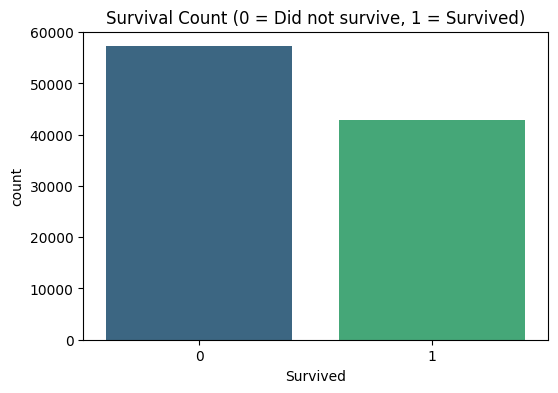

In [5]:
# %%
# Visualization 1 - Survival count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train, palette='viridis')
plt.title('Survival Count (0 = Did not survive, 1 = Survived)')
plt.show()



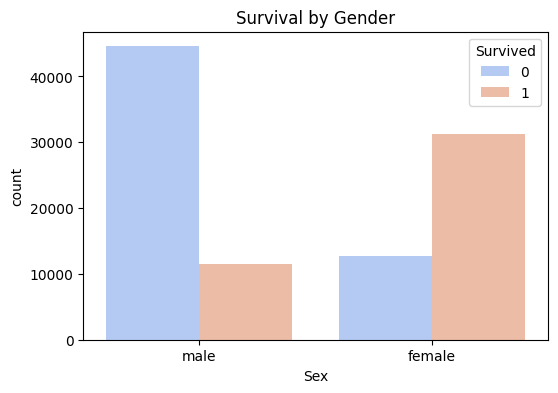

In [6]:
# %%
# Visualization 2 - Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train, palette='coolwarm')
plt.title('Survival by Gender')
plt.show()



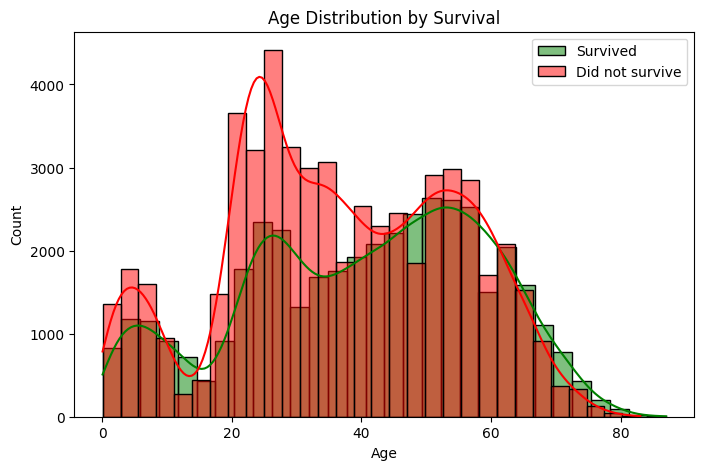

In [7]:
# %%
# Visualization 3 - Age distribution by survival
plt.figure(figsize=(8,5))
sns.histplot(train[train['Survived']==1]['Age'], bins=30, color='green', label='Survived', kde=True)
sns.histplot(train[train['Survived']==0]['Age'], bins=30, color='red', label='Did not survive', kde=True)
plt.legend()
plt.title('Age Distribution by Survival')
plt.show()



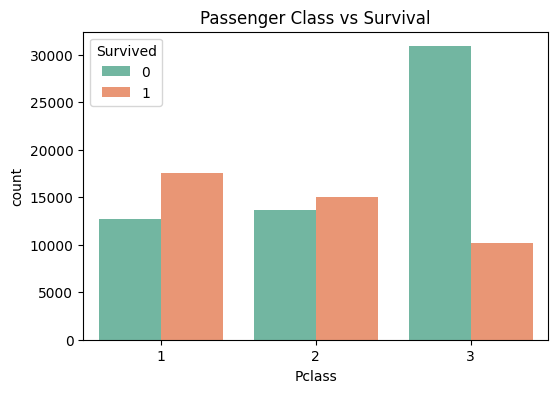

In [8]:
# %%
# Visualization 4 - Pclass vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=train, palette='Set2')
plt.title('Passenger Class vs Survival')
plt.show()



In [9]:
# %%
# Feature Engineering
def extract_title(name):
    if pd.isna(name):
        return 'Unknown'
    parts = name.split(',')
    if len(parts) > 1:
        title_part = parts[1].strip().split(' ')[0]
        return title_part.replace('.', '')
    return 'Unknown'

for df in [train, test] if test is not None else [train]:
    df['Title'] = df['Name'].apply(extract_title)
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace('Mme','Mrs')
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts()<10].index
    df['Title'] = df['Title'].replace(rare_titles,'Rare')

features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Title']
X = train[features].copy()
y = train['Survived'].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)



In [10]:
# %%
# Preprocessing
numeric_features = ['Age','SibSp','Parch','Fare']
numeric_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])

categorical_features = ['Pclass','Sex','Embarked','Title']
categorical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num',numeric_transformer,numeric_features),('cat',categorical_transformer,categorical_features)])

rf_pipeline = Pipeline(steps=[('preprocessor',preprocessor),('classifier',RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE))])

# %%
# Train model
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_val)
y_proba = rf_pipeline.predict_proba(X_val)[:,1]

print('Accuracy:', accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))



Accuracy: 0.74725
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     11445
           1       0.71      0.70      0.70      8555

    accuracy                           0.75     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.75      0.75      0.75     20000



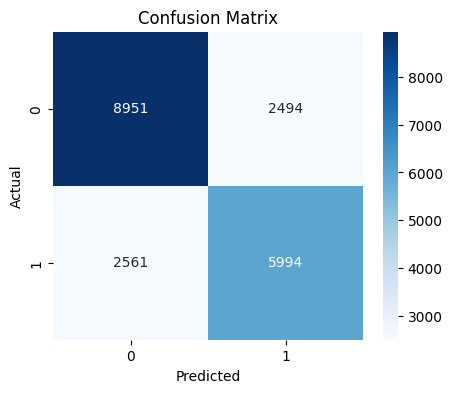

In [11]:
# %%
# Confusion matrix plot
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



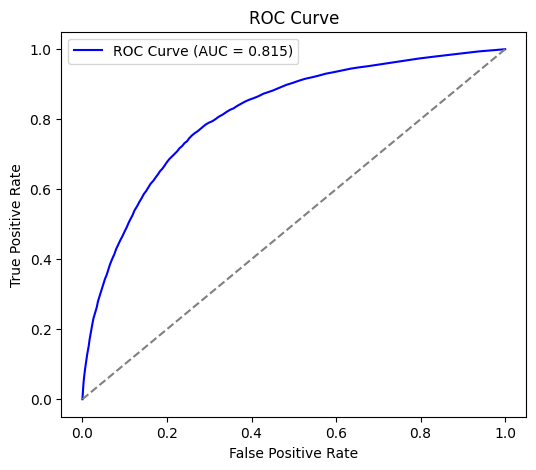

In [12]:
# %%
# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_val, y_proba):.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()



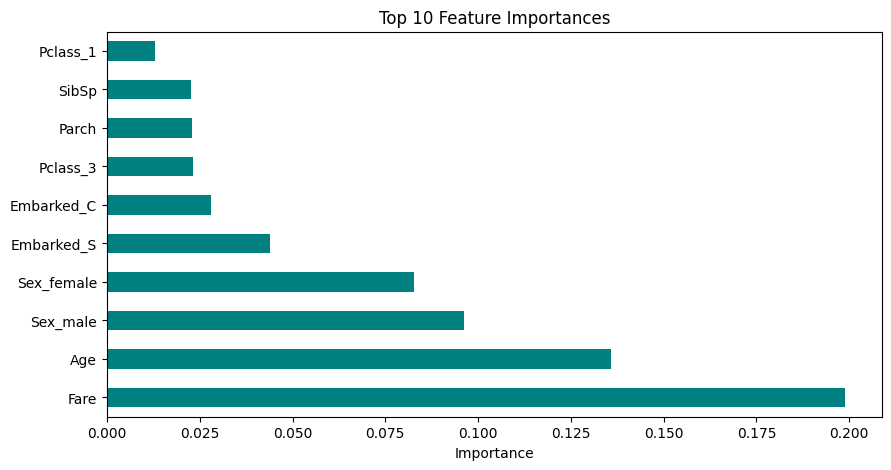

Top Features:
 Fare          0.198884
Age           0.135879
Sex_male      0.096237
Sex_female    0.082832
Embarked_S    0.043807
Embarked_C    0.028092
Pclass_3      0.023235
Parch         0.022976
SibSp         0.022581
Pclass_1      0.013008
dtype: float64
Model saved as titanic_model.pkl


In [13]:
# %%
# Feature Importances
rf_pipeline.named_steps['preprocessor'].fit(X_train)
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

print('Top Features:\n', feat_imp.head(10))

# %%
# Save model
with open('titanic_model.pkl','wb') as f:
    pickle.dump(rf_pipeline, f)
print('Model saved as titanic_model.pkl')
